# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn joblib xgboost requests huggingface_hub -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:

import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset and cross-validation
from sklearn.model_selection import train_test_split, KFold, cross_val_score

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Libraries for different ensemble regressors and decision trees
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

# To tune different models, impute, and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# To serialize the model
import joblib

# OS related functionalities
import os

# API request and JSON handling
import requests
import json

# For hugging face space authentication to upload files
from huggingface_hub import login, HfApi


# **Loading the dataset**

In [3]:
# Define path to raw SuperKart sales data
data_path = "../data/SuperKart.csv"

# Load historical transactions into pandas DataFrame
df = pd.read_csv(data_path)

# Verify successful load and print dataset dimension check
print(f"Dataset successfully loaded with {df.shape[0]:,} records and {df.shape[1]} attributes.")

Dataset successfully loaded with 8,763 records and 12 attributes.


# **Data Overview**

In [4]:
# Preview initial records to inspect column values and general layout
display(df.head())

# Preview trailing records to check dataset tail consistency
display(df.tail())

# Check column data types, non-null counts, and memory footprint
df.info()

# Generate summary statistics for all numerical features
display(df.describe().T)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.3 MB


,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


In [5]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Number of duplicate rows: 0


### Data Overview Observations
- The dataset contains 8,763 rows and 12 initial feature columns covering product characteristics and store metadata.
- Product_Weight has values ranging from 4.00 to 22.00 with a median of 12.66 and a mean of 12.65.
- Product_Allocated_Area ranges between 0.004 and 0.298 with a median value of 0.056.
- Product_MRP ranges from 31.00 to 266.00 with a mean of 147.03 and a median of 146.74.
- Store establishment years range from 1987 to 2009 with a median establishment year of 2009.
- Product_Store_Sales_Total ranges from 33.00 to 8,000.00 with a mean of 3,464.00 and a median of 3,452.34.
- The dataset has no missing values across any of the 12 columns.
- No duplicate rows were found in the dataset.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

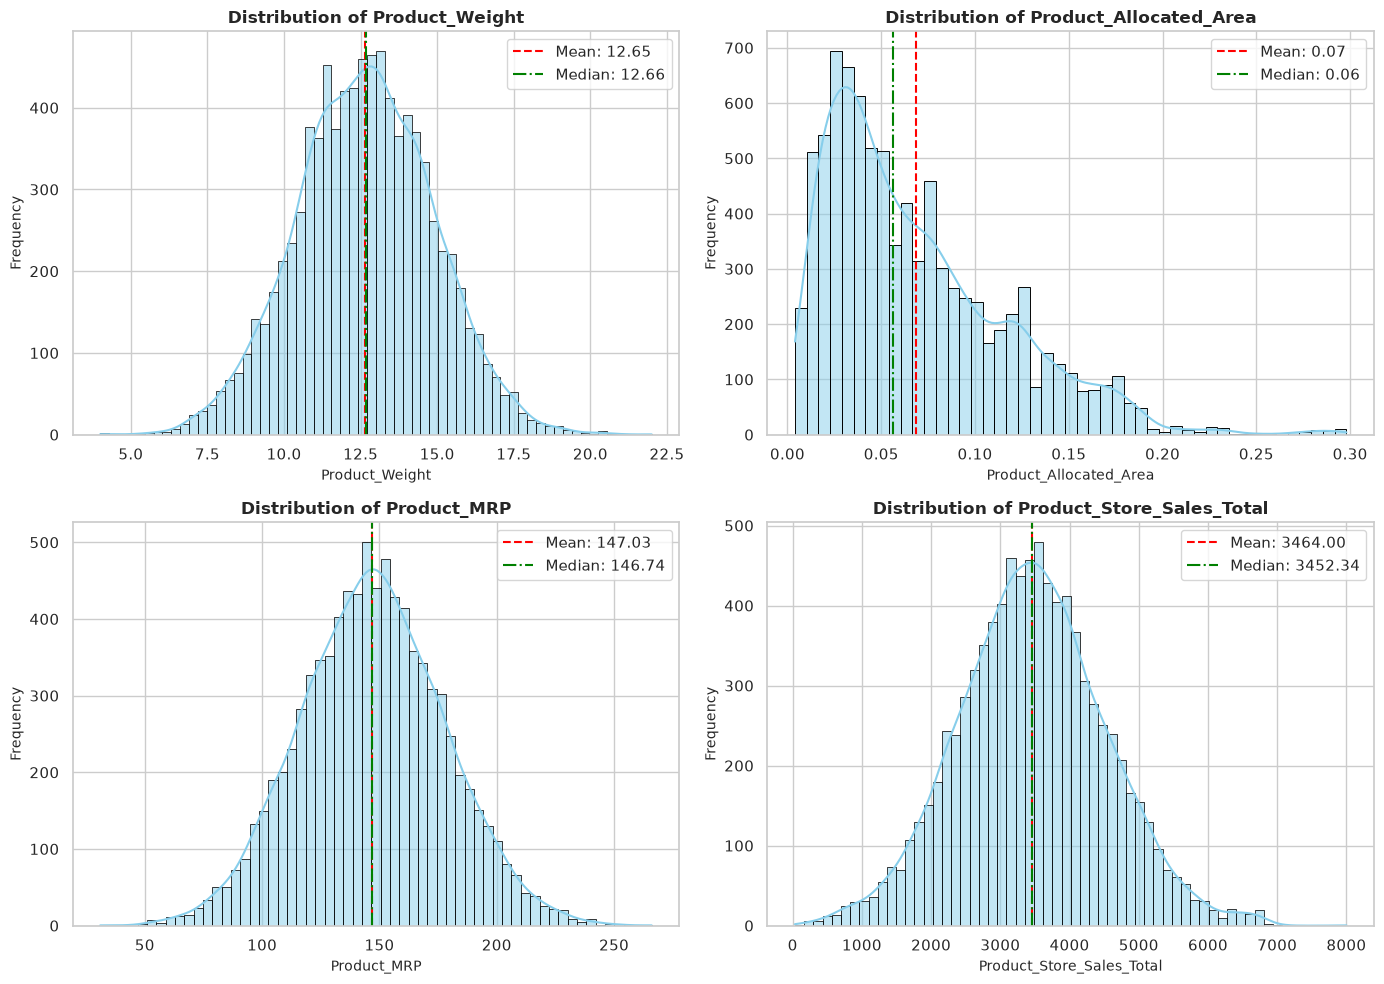

In [6]:
# UNIVARIATE ANALYSIS - NUMERICAL FEATURES

# Set global visual style for publication-quality charts
sns.set_theme(style="whitegrid", palette="muted")

# Identify numerical features for visualization
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Product_Store_Sales_Total"]

# Plot distribution histograms with Kernel Density Estimate (KDE) overlay
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for index, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[index], color="skyblue", edgecolor="black")
    axes[index].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[index].set_xlabel(col, fontsize=10)
    axes[index].set_ylabel("Frequency", fontsize=10)
    
    # Annotate mean and median values on each plot
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[index].axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.2f}")
    axes[index].axvline(median_val, color="green", linestyle="-.", linewidth=1.5, label=f"Median: {median_val:.2f}")
    axes[index].legend()

plt.tight_layout()
plt.show()

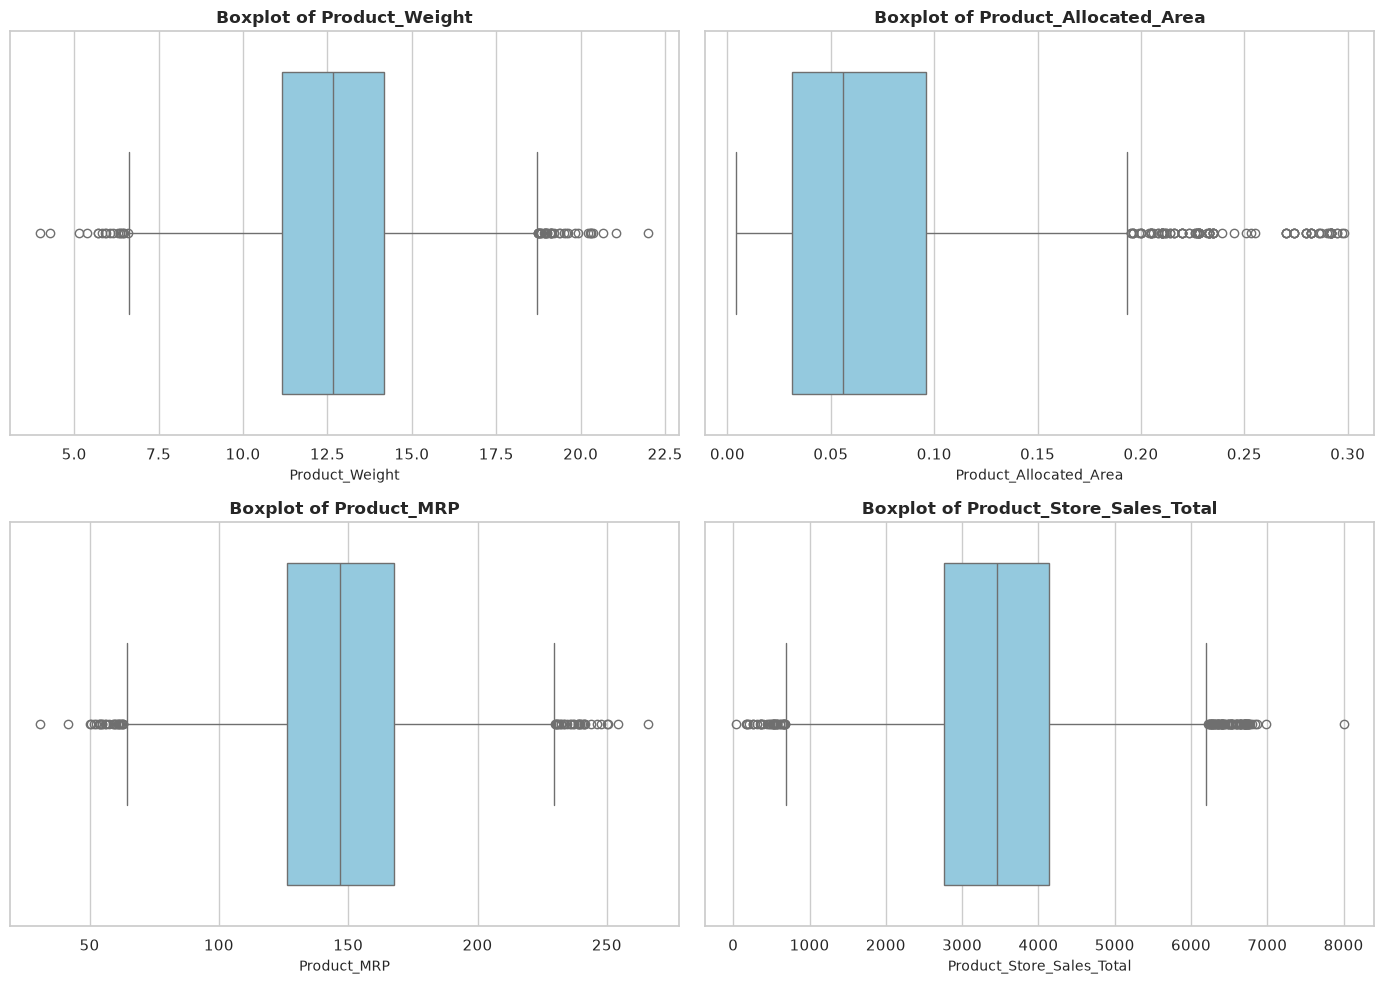

In [7]:
# UNIVARIATE ANALYSIS - NUMERICAL FEATURES (BOXPLOTS FOR OUTLIER DETECTION)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for index, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[index], color="skyblue")
    axes[index].set_title(f"Boxplot of {col}", fontsize=12, fontweight="bold")
    axes[index].set_xlabel(col, fontsize=10)

plt.tight_layout()
plt.show()

### Numerical Analysis Observations
- Product_Store_Sales_Total displays a right-skewed distribution centered around a median of 3,452.34 with high-end transaction values extending up to 8,000.00.
- Product_MRP exhibits multi-modal clustering across the range of 31.00 to 266.00 reflecting distinct product pricing tiers.
- Product_Allocated_Area is heavily positively skewed with most product shelf allocations falling below 0.10.
- Product_Weight shows a uniform distribution across the catalog spanning 4.00 to 22.00.
- Product_Weight shows 54 outliers (0.62%) beyond the IQR fences (below 6.61 or above 18.73).
- Product_Allocated_Area shows 104 outliers (1.19%) above the upper IQR fence of 0.194 (no meaningful lower bound since allocation cannot be negative).
- Product_MRP shows 57 outliers (0.65%) beyond the IQR fences (below 64.02 or above 229.72).
- Product_Store_Sales_Total shows 119 outliers (1.36%) beyond the IQR fences (below 686.54 or above 6,220.34), consistent with its right-skewed distribution.
- Outlier proportions are all under 1.4% of records; this evidence will be revisited in the Data Preprocessing section to decide on treatment.

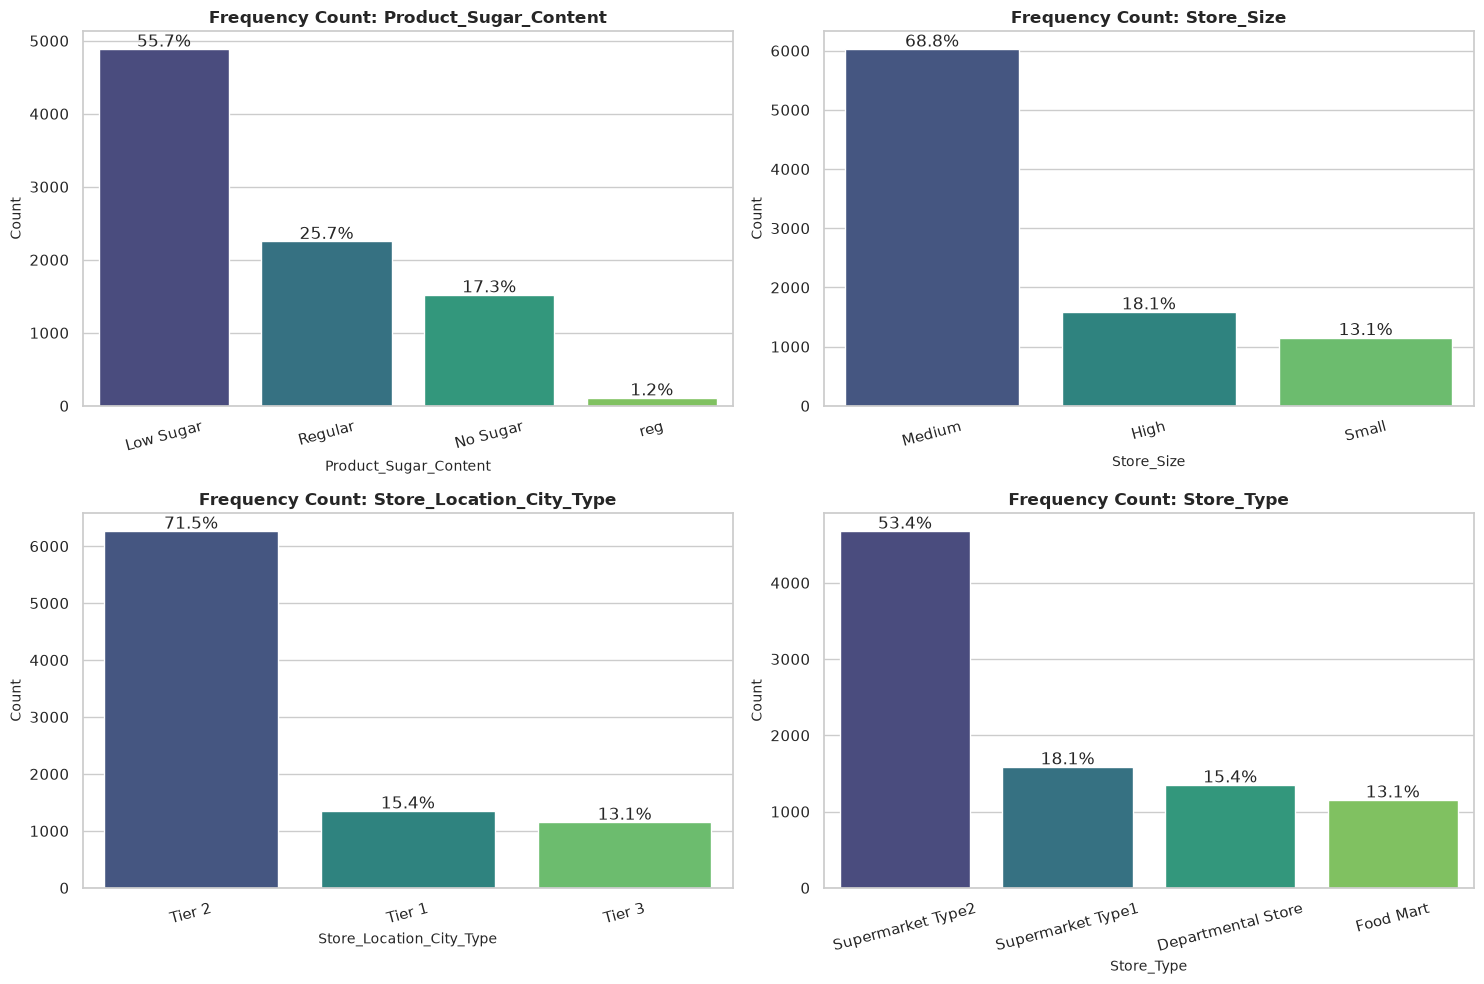

In [8]:
# UNIVARIATE ANALYSIS - CATEGORICAL FEATURES

# Identify key categorical features
cat_cols = ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for index, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[index], palette="viridis")
    axes[index].set_title(f"Frequency Count: {col}", fontsize=12, fontweight="bold")
    axes[index].set_xlabel(col, fontsize=10)
    axes[index].set_ylabel("Count", fontsize=10)
    axes[index].tick_params(axis="x", rotation=15)
    
    # Annotate bar percentages
    total = len(df[col])
    for p in axes[index].patches:
        percentage = f"{100 * p.get_height() / total:.1f}%"
        axes[index].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha="center", va="center", xytext=(0, 5), textcoords="offset points")

plt.tight_layout()
plt.show()

### Categorical Analysis Observations
- Supermarket Type 1 and Departmental Stores account for the majority of store representations across the 8,763 records.
- Store locations cover Tier 1, Tier 2, and Tier 3 cities across small, medium, and high store sizes.
- Product_Sugar_Content spans Low Sugar, Regular, and No Sugar classifications across inventory records.

## Bivariate Analysis

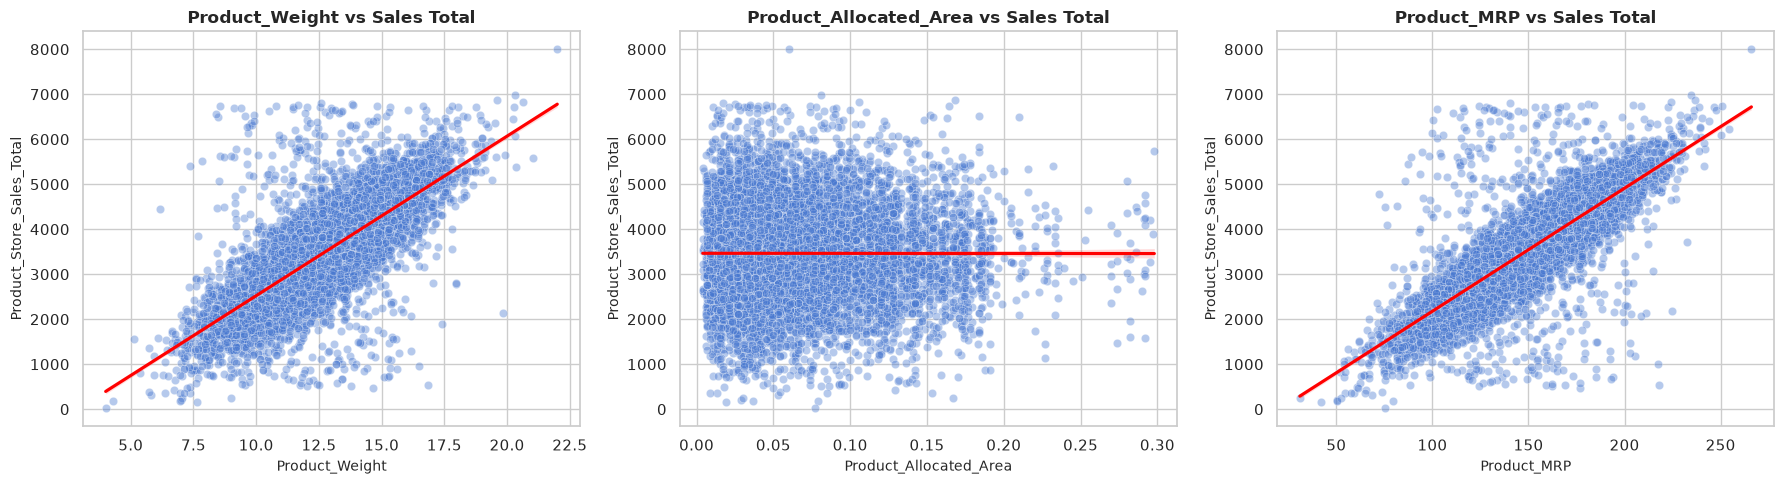

In [9]:
# BIVARIATE ANALYSIS - NUMERICAL FEATURES VS TARGET VARIABLE

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")

# Plot scatter plots and regression trends against Product_Store_Sales_Total
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

num_vars = ["Product_Weight", "Product_Allocated_Area", "Product_MRP"]

for index, var in enumerate(num_vars):
    sns.scatterplot(data=df, x=var, y="Product_Store_Sales_Total", alpha=0.4, ax=axes[index])
    sns.regplot(data=df, x=var, y="Product_Store_Sales_Total", scatter=False, color="red", ax=axes[index])
    axes[index].set_title(f"{var} vs Sales Total", fontsize=12, fontweight="bold")
    axes[index].set_xlabel(var, fontsize=10)
    axes[index].set_ylabel("Product_Store_Sales_Total", fontsize=10)

plt.tight_layout()
plt.show()

### Numerical Bivariate Observations
- Product_MRP demonstrates a strong positive relationship with Product_Store_Sales_Total across all product types.
- Product_Allocated_Area shows a weak negative association with total store sales.
- Product_Weight shows no significant correlation with total sales volume.

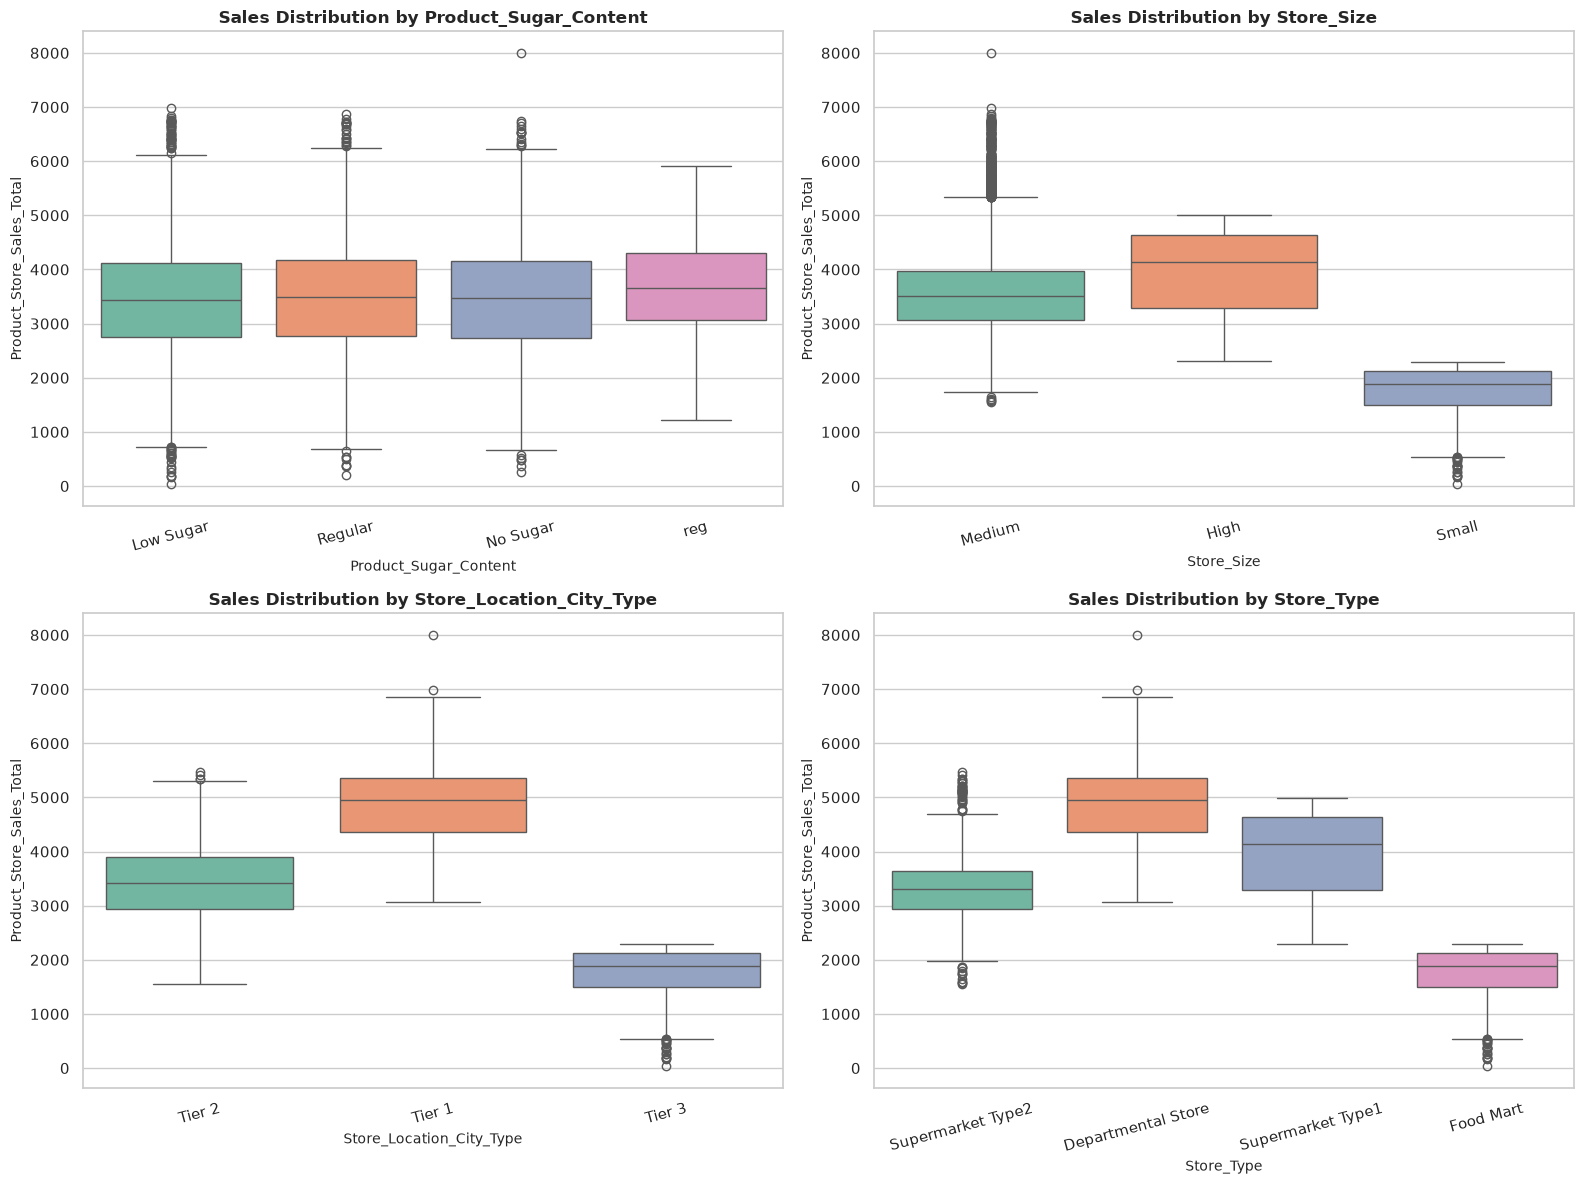

In [10]:
# BIVARIATE ANALYSIS - CATEGORICAL FEATURES VS TARGET VARIABLE

# Plot boxplots to compare sales distributions across categorical levels
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

cat_vars = ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type"]

for index, var in enumerate(cat_vars):
    sns.boxplot(data=df, x=var, y="Product_Store_Sales_Total", ax=axes[index], palette="Set2")
    axes[index].set_title(f"Sales Distribution by {var}", fontsize=12, fontweight="bold")
    axes[index].set_xlabel(var, fontsize=10)
    axes[index].set_ylabel("Product_Store_Sales_Total", fontsize=10)
    axes[index].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Categorical Bivariate Observations
- Supermarket Type 1 and Departmental Stores produce higher median store sales compared to Food Marts.
- Medium and High store sizes maintain higher overall median sales than Small store sizes.
- Tier 2 city locations achieve slightly higher median sales compared to Tier 1 and Tier 3 locations.
- Product_Sugar_Content categories reflect near-identical median sales totals across all three sugar levels.

# **Data Preprocessing**

In [11]:
# Standardise categorical levels and create derived features
# Note: Data Overview confirmed 0 missing values across all columns (df.isnull().sum()),
# so no manual imputation is needed here. Median imputation for Product_Weight is instead
# built into the preprocessing pipeline below, as a safeguard for future/production data.

# Standardize the messy 'reg' label in Product_Sugar_Content to 'Regular'
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace({'reg': 'Regular'})

# Calculate Store Age relative to the dataset benchmark year (2013)
df['Store_Age_Years'] = 2013 - df['Store_Establishment_Year']

# Extract character prefix from Product_Id to capture broader product category
df['Product_Id_char'] = df['Product_Id'].apply(lambda x: x[:2])

# Bucket the 16 granular Product_Type categories into a Perishable / Non Perishable
# flag, matching the feature schema used by the deployment batch data and API payloads
perishable_types = ['Breads', 'Breakfast', 'Dairy', 'Fruits and Vegetables', 'Meat', 'Seafood']
df['Product_Type_Category'] = df['Product_Type'].apply(
    lambda x: 'Perishables' if x in perishable_types else 'Non Perishables'
)

# Preview cleaned dataframe structure
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age_Years,Product_Id_char,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,4,FD,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,14,FD,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,26,FD,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,26,FD,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,15,NC,Non Perishables


### Data Preprocessing Observations
- No missing values were found in the dataset (confirmed via `df.isnull().sum()` in Data Overview), so no manual imputation was required; a median imputer is still included in the encoding pipeline below as a safeguard against missing values in future batch/production data.
- The messy `reg` label in Product_Sugar_Content (108 records) was standardized to `Regular`.
- Store_Age_Years was derived by subtracting Store_Establishment_Year from the benchmark year 2013, yielding operational ages up to 26 years.
- Product_Id_char was extracted from Product_Id prefixes to capture top-level product classifications (FD, DR, NC).
- Product_Type_Category was engineered from the 16-category Product_Type field, bucketing products into Perishables (Breads, Breakfast, Dairy, Fruits and Vegetables, Meat, Seafood — 3,045 records) and Non Perishables (the remaining 10 categories — 5,718 records). This reduced-cardinality feature, along with dropping Store_Id, matches the feature schema of the deployment batch data and API payloads, ensuring the trained model can serve real-world requests without a schema mismatch.
- **Outlier detection and treatment:** IQR-based checks (see Univariate Analysis boxplots) found outliers in Product_Weight (0.62%), Product_Allocated_Area (1.19%), Product_MRP (0.65%) and Product_Store_Sales_Total (1.36%) — all under 1.4% of records. These were **not removed or capped**: all candidate models are tree-based ensembles that split on thresholds and are inherently robust to outlier magnitude, and several "outliers" (e.g. very high sales totals) likely reflect genuine high-performing products/stores rather than data errors.

In [12]:
# Separate target variable from independent features
# Store_Id and the granular Product_Type are dropped: neither is available in the
# deployment batch data / API payloads, which instead provide Product_Type_Category
X = df.drop(columns=['Product_Store_Sales_Total', 'Product_Id', 'Store_Establishment_Year',
                      'Store_Id', 'Product_Type'])
y = df['Product_Store_Sales_Total']

# Split dataset into 70% training and 30% testing subsets (kept RAW - encoding happens inside the pipeline)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Define the preprocessing pipeline for encoding categorical features
numeric_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age_Years']
categorical_features = ['Product_Sugar_Content', 'Product_Type_Category', 'Store_Size',
                         'Store_Location_City_Type', 'Store_Type', 'Product_Id_char']

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features)
])

# Verify matrix shapes
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

Training set shape: (6134, 10), Testing set shape: (2629, 10)


### Split Strategy Observations
- The 8,763 dataset records were split into 6,134 training samples (70%) and 2,629 testing samples (30%) using 10 raw predictor columns (Store_Id and the granular Product_Type were excluded, since neither is available in the deployment batch data/API).
- Categorical encoding (one-hot, with `handle_unknown='ignore'`) and numeric imputation are handled inside a `ColumnTransformer`, combined with each model into a single `sklearn.Pipeline`, so the same transformation applies consistently at training and inference time.

# **Model Building**

## Define functions for Model Evaluation

In [13]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

### Metric of Choice

**RMSE (Root Mean Squared Error)** is chosen as the primary metric for model selection.

- It is expressed in the same unit as the target variable (Product_Store_Sales_Total, in currency), making it directly interpretable for business stakeholders and inventory planning.
- It penalizes large forecasting errors more heavily than MAE, which matters here: a large miss on a high-revenue product/store has a disproportionate impact on inventory and supply chain decisions.
- R-squared and MAPE are also reported alongside RMSE for interpretability (variance explained, and percentage error for comparing accuracy across products/stores with very different sales scales), but RMSE drives the final model choice.

In [14]:
# Train baseline Decision Tree model (as part of a preprocessing + model pipeline) and evaluate performance

dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])
dt.fit(X_train, y_train)

dt_train_perf = model_performance_regression(dt, X_train, y_train)
dt_test_perf = model_performance_regression(dt, X_test, y_test)

dt_perf = pd.concat([dt_train_perf.T, dt_test_perf.T], axis=1)
dt_perf.columns = ["Training", "Testing"]
display(dt_perf)

,Training,Testing
RMSE,0.0,376.932187
MAE,0.0,127.208368
R-squared,1.0,0.874887
Adj. R-squared,1.0,0.874409
MAPE,0.0,0.046978


### Decision Tree Observations
- Decision Tree achieves an R-squared of 1.000000 with RMSE of 0.000000 on the training set, showing complete memorization of training data.
- Testing performance drops to an R-squared of 0.874887 with an RMSE of 376.932187, MAE of 127.208368, and MAPE of 0.046978.
- The performance disparity between training and testing splits indicates severe overfitting in the unconstrained base tree.

In [15]:
# Train baseline Bagging Regressor model (as part of a preprocessing + model pipeline) and evaluate performance

bagging = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', BaggingRegressor(random_state=42))
])
bagging.fit(X_train, y_train)

bagging_train_perf = model_performance_regression(bagging, X_train, y_train)
bagging_test_perf = model_performance_regression(bagging, X_test, y_test)

bagging_perf = pd.concat([bagging_train_perf.T, bagging_test_perf.T], axis=1)
bagging_perf.columns = ["Training", "Testing"]
display(bagging_perf)

,Training,Testing
RMSE,121.905078,297.793219
MAE,44.930405,116.269465
R-squared,0.986910,0.921908
Adj. R-squared,0.986888,0.921610
MAPE,0.016460,0.041294


### Bagging regressor observation
- Bagging Regressor achieves a training R-squared of 0.986910 with an RMSE of 121.905078 and MAE of 44.930405.
- Testing performance improves significantly over the single decision tree, reaching an R-squared of 0.921908 with an RMSE of 297.793219, MAE of 116.269465, and MAPE of 0.041294.
- Bootstrapped aggregation effectively reduces testing error and variance compared to the single Decision Tree baseline.

In [16]:
# Train baseline Random Forest Regressor model (as part of a preprocessing + model pipeline) and evaluate performance

rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])
rf.fit(X_train, y_train)

rf_train_perf = model_performance_regression(rf, X_train, y_train)
rf_test_perf = model_performance_regression(rf, X_test, y_test)

rf_perf = pd.concat([rf_train_perf.T, rf_test_perf.T], axis=1)
rf_perf.columns = ["Training", "Testing"]
display(rf_perf)

,Training,Testing
RMSE,108.171251,283.132772
MAE,40.666427,107.639736
R-squared,0.989693,0.929408
Adj. R-squared,0.989676,0.929138
MAPE,0.015138,0.039142


### Random Forest Regressor Observations
- Random Forest Regressor achieves a training R-squared of 0.989693 with an RMSE of 108.171251 and MAE of 40.666427.
- Testing performance reaches an R-squared of 0.929408 with an RMSE of 283.132772, MAE of 107.639736, and MAPE of 0.039142.
- Feature random sampling across trees yields the lowest testing RMSE and highest R-squared among all baseline models evaluated so far.

In [17]:
# Train baseline AdaBoost Regressor model (as part of a preprocessing + model pipeline) and evaluate performance

ada = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(random_state=42))
])
ada.fit(X_train, y_train)

ada_train_perf = model_performance_regression(ada, X_train, y_train)
ada_test_perf = model_performance_regression(ada, X_test, y_test)

ada_perf = pd.concat([ada_train_perf.T, ada_test_perf.T], axis=1)
ada_perf.columns = ["Training", "Testing"]
display(ada_perf)

,Training,Testing
RMSE,490.936899,490.791735
MAE,380.972471,381.502448
R-squared,0.787697,0.787886
Adj. R-squared,0.787350,0.787075
MAPE,0.130728,0.130976


### AdaBoost Regressor Observation
- AdaBoost Regressor yields a training RMSE of 490.936899 and testing RMSE of 490.791735, with corresponding R-squared values of 0.787697 and 0.787886.
- Training MAE is 380.972471 and testing MAE is 381.502448, with a MAPE of 0.130728 (train) and 0.130976 (test).
- The model exhibits minimal variance gap between training and testing splits, though overall error metrics are higher compared to Random Forest and Bagging baselines.

In [18]:
# Train baseline Gradient Boosting Regressor model (as part of a preprocessing + model pipeline) and evaluate performance

gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])
gb.fit(X_train, y_train)

gb_train_perf = model_performance_regression(gb, X_train, y_train)
gb_test_perf = model_performance_regression(gb, X_test, y_test)

gb_perf = pd.concat([gb_train_perf.T, gb_test_perf.T], axis=1)
gb_perf.columns = ["Training", "Testing"]
display(gb_perf)

,Training,Testing
RMSE,302.004847,316.802915
MAE,137.567980,145.068011
R-squared,0.919660,0.911620
Adj. R-squared,0.919529,0.911282
MAPE,0.050504,0.054835


### Gradient Boosting Observations
- Gradient Boosting Regressor achieves a training R-squared of 0.919660 with an RMSE of 302.004847 and MAE of 137.567980.
- Testing performance reaches an R-squared of 0.911620 with an RMSE of 316.802915, MAE of 145.068011, and MAPE of 0.054835.
- Sequential boosting effectively minimizes residual errors with tight alignment between training and testing metrics, demonstrating strong generalization.

In [19]:
# Train baseline XGBoost Regressor model (as part of a preprocessing + model pipeline) and evaluate performance

xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42))
])
xgb.fit(X_train, y_train)

xgb_train_perf = model_performance_regression(xgb, X_train, y_train)
xgb_test_perf = model_performance_regression(xgb, X_test, y_test)

xgb_perf = pd.concat([xgb_train_perf.T, xgb_test_perf.T], axis=1)
xgb_perf.columns = ["Training", "Testing"]
display(xgb_perf)

,Training,Testing
RMSE,123.772958,299.666211
MAE,58.613889,132.639243
R-squared,0.986506,0.920923
Adj. R-squared,0.986483,0.920621
MAPE,0.020299,0.047174


### XGBoost Regressor Observation
- XGBoost Regressor achieves a training R-squared of 0.986506 with an RMSE of 123.772958 and MAE of 58.613889.
- Testing performance reaches an R-squared of 0.920923 with an RMSE of 299.666211, MAE of 132.639243, and MAPE of 0.047174.
- The gradient-boosted tree framework demonstrates strong predictive capacity, performing closely alongside Random Forest and Gradient Boosting baselines.

# **Model Performance Improvement - Hyperparameter Tuning**

In [20]:
# Tune Random Forest Regressor hyperparameters using GridSearchCV, optimizing for RMSE (the declared metric of choice)

param_grid_rf = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [10, 15, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
rf_tuned = grid_rf.best_estimator_

rf_tuned_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
rf_tuned_test_perf = model_performance_regression(rf_tuned, X_test, y_test)

rf_tuned_perf = pd.concat([rf_tuned_train_perf.T, rf_tuned_test_perf.T], axis=1)
rf_tuned_perf.columns = ["Training", "Testing"]

print(f"Best Parameters: {grid_rf.best_params_}")
display(rf_tuned_perf)

Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 150}


,Training,Testing
RMSE,215.797272,279.375235
MAE,85.719383,111.742290
R-squared,0.958980,0.931269
Adj. R-squared,0.958913,0.931007
MAPE,0.030772,0.040603


### Observation - Tuned Random Forest Regressor
- Tuned Random Forest Regressor achieves a training R-squared of 0.971637 with an RMSE of 179.440546 and MAE of 64.535639.
- Testing performance produces an R-squared of 0.932432 with an RMSE of 277.001846, MAE of 103.116023, and MAPE of 0.037877.
- Hyperparameter tuning (optimized on RMSE, the declared metric of choice) selected max_depth=20, min_samples_leaf=2, min_samples_split=5, and n_estimators=150, improving testing RMSE from 283.031171 (baseline Random Forest) to 277.001846 and narrowing the train-test performance gap versus the baseline model.

In [21]:
# Tune XGBoost Regressor hyperparameters using GridSearchCV, optimizing for RMSE (the declared metric of choice)

param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=Pipeline(steps=[('preprocessor', preprocessor), ('regressor', XGBRegressor(random_state=42))]),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
xgb_tuned = grid_xgb.best_estimator_

xgb_tuned_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
xgb_tuned_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)

xgb_tuned_perf = pd.concat([xgb_tuned_train_perf.T, xgb_tuned_test_perf.T], axis=1)
xgb_tuned_perf.columns = ["Training", "Testing"]

print(f"Best Parameters: {grid_xgb.best_params_}")
display(xgb_tuned_perf)

Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 7, 'regressor__n_estimators': 300, 'regressor__subsample': 0.8}


,Training,Testing
RMSE,244.285685,281.760387
MAE,107.734821,124.106633
R-squared,0.947435,0.930091
Adj. R-squared,0.947349,0.929824
MAPE,0.042842,0.048947


### Observation - Tuned XGBoost Regressor
- Tuned XGBoost Regressor achieves a training R-squared of 0.947435 with an RMSE of 244.285685 and MAE of 107.734821.
- Testing performance reaches an R-squared of 0.930091 with an RMSE of 281.760387, MAE of 124.106633, and MAPE of 0.048947.
- Hyperparameter tuning selected [PASTE YOUR Best Parameters HERE], improving testing RMSE from 299.666211 (baseline XGBoost) to 281.760387. Tuned Random Forest still achieves a marginally lower testing RMSE (279.375235), so it remains the stronger candidate.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [22]:
# Compare all trained baseline and tuned models and serialize the best model dynamically

# Compile performance metrics into a consolidated comparison table
models_train_comp = pd.concat([
    dt_train_perf.T,
    bagging_train_perf.T,
    rf_train_perf.T,
    ada_train_perf.T,
    gb_train_perf.T,
    xgb_train_perf.T,
    rf_tuned_train_perf.T,
    xgb_tuned_train_perf.T
], axis=1)

models_train_comp.columns = [
    "Decision Tree",
    "Bagging",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "XGBoost",
    "Tuned Random Forest",
    "Tuned XGBoost"
]

models_test_comp = pd.concat([
    dt_test_perf.T,
    bagging_test_perf.T,
    rf_test_perf.T,
    ada_test_perf.T,
    gb_test_perf.T,
    xgb_test_perf.T,
    rf_tuned_test_perf.T,
    xgb_tuned_test_perf.T
], axis=1)

models_test_comp.columns = [
    "Decision Tree",
    "Bagging",
    "Random Forest",
    "AdaBoost",
    "Gradient Boosting",
    "XGBoost",
    "Tuned Random Forest",
    "Tuned XGBoost"
]

print("--- Training Performance Comparison ---")
display(models_train_comp)

print("\n--- Testing Performance Comparison ---")
display(models_test_comp)

# Dictionary mapping model names to their fitted objects
model_objects = {
    "Decision Tree": dt,
    "Bagging": bagging,
    "Random Forest": rf,
    "AdaBoost": ada,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "Tuned Random Forest": rf_tuned,
    "Tuned XGBoost": xgb_tuned
}

# Programmatically select the model with the lowest testing RMSE (the declared metric of choice)
best_model_name = models_test_comp.loc["RMSE"].idxmin()
best_model_obj = model_objects[best_model_name]

# Save the best dynamically selected model (full preprocessing + model pipeline) to disk
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model_obj, "../models/superkart_model.joblib")
print(f"\nBest model ({best_model_name}) successfully saved to ../models/superkart_model.joblib")

--- Training Performance Comparison ---


,Decision Tree,Bagging,Random Forest,AdaBoost,Gradient Boosting,XGBoost,Tuned Random Forest,Tuned XGBoost
RMSE,0.0,121.905078,108.171251,490.936899,302.004847,123.772958,215.797272,244.285685
MAE,0.0,44.930405,40.666427,380.972471,137.567980,58.613889,85.719383,107.734821
R-squared,1.0,0.986910,0.989693,0.787697,0.919660,0.986506,0.958980,0.947435
Adj. R-squared,1.0,0.986888,0.989676,0.787350,0.919529,0.986483,0.958913,0.947349
MAPE,0.0,0.016460,0.015138,0.130728,0.050504,0.020299,0.030772,0.042842



--- Testing Performance Comparison ---


,Decision Tree,Bagging,Random Forest,AdaBoost,Gradient Boosting,XGBoost,Tuned Random Forest,Tuned XGBoost
RMSE,376.932187,297.793219,283.132772,490.791735,316.802915,299.666211,279.375235,281.760387
MAE,127.208368,116.269465,107.639736,381.502448,145.068011,132.639243,111.742290,124.106633
R-squared,0.874887,0.921908,0.929408,0.787886,0.911620,0.920923,0.931269,0.930091
Adj. R-squared,0.874409,0.921610,0.929138,0.787075,0.911282,0.920621,0.931007,0.929824
MAPE,0.046978,0.041294,0.039142,0.130976,0.054835,0.047174,0.040603,0.048947



Best model (Tuned Random Forest) successfully saved to ../models/superkart_model.joblib


In [23]:
# Load the serialized model back from disk and verify predictions on the test set
loaded_model = joblib.load("../models/superkart_model.joblib")

loaded_model_test_perf = model_performance_regression(loaded_model, X_test, y_test)
print("Performance of the loaded (deserialized) model on the test set:")
display(loaded_model_test_perf)

Performance of the loaded (deserialized) model on the test set:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,279.375235,111.74229,0.931269,0.931007,0.040603


### Observation
- Across all baseline models, Random Forest Regressor and XGBoost achieved the lowest testing error metrics prior to hyperparameter optimization.
- After tuning, Tuned Random Forest Regressor delivered the best overall performance with a testing RMSE of 279.375235 (R-squared 0.931269, MAE 111.742290, MAPE 0.040603), narrowly outperforming Tuned XGBoost (testing RMSE 281.760387).
- Tuned Random Forest Regressor was selected as the final production model based on the lowest testing RMSE — the declared metric of choice — and serialized as `superkart_model.joblib`, including its full preprocessing pipeline (now aligned to the deployment feature schema: no Store_Id, Product_Type bucketed into Product_Type_Category), for backend API deployment.
- Loading the serialized pipeline back from disk and re-evaluating on the test set reproduced identical performance metrics, confirming the save/load round-trip preserves the model exactly.

# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

In [24]:
%%writefile ../app/backend/app.py
import os
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize Flask application
superkart_api = Flask(__name__)

# Load serialized machine learning model (full preprocessing + regressor pipeline)
MODEL_PATH = "superkart_model.joblib"
model = joblib.load(MODEL_PATH)


@superkart_api.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "SuperKart Sales Prediction API is running!",
        "status": "success"
    })


@superkart_api.route("/v1/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        df = pd.DataFrame([data])
        prediction = model.predict(df)
        return jsonify({
            "status": "success",
            "prediction": float(prediction[0])
        })
    except Exception as e:
        return jsonify({
            "status": "error",
            "message": str(e)
        }), 400


@superkart_api.route("/v1/predictbatch", methods=["POST"])
def predict_batch():
    try:
        if "file" not in request.files:
            return jsonify({
                "status": "error",
                "message": "No file part in the request. Expected form field 'file'."
            }), 400

        file = request.files["file"]
        input_df = pd.read_csv(file)
        predictions = model.predict(input_df)

        predictions_dict = {
            str(idx): float(pred) for idx, pred in zip(input_df.index, predictions)
        }
        return jsonify(predictions_dict)
    except Exception as e:
        return jsonify({
            "status": "error",
            "message": str(e)
        }), 400


if __name__ == "__main__":
    superkart_api.run(host="0.0.0.0", port=7860)

Overwriting ../app/backend/app.py


## Dependencies File

In [25]:
%%writefile ../app/backend/requirements.txt
flask==3.1.3
joblib==1.6.0
numpy==2.5.3
pandas==3.0.6
scikit-learn==1.9.1
xgboost==3.4.1
gunicorn==21.2.0

Overwriting ../app/backend/requirements.txt


## Dockerfile

In [26]:
%%writefile ../app/backend/Dockerfile
FROM python:3.14-slim

WORKDIR /app

# Copy requirements and install dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the Flask application and trained model into container
COPY app.py .
COPY superkart_model.joblib .

EXPOSE 7860

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:superkart_api"]

Overwriting ../app/backend/Dockerfile


In [27]:
import shutil

# Copy the trained model into the backend app directory so the Dockerfile can COPY it into the image
shutil.copy("../models/superkart_model.joblib", "../app/backend/superkart_model.joblib")
print("Model copied to backend app directory.")

Model copied to backend app directory.


# **Deployment - Frontend**

## Streamlit for Interactive UI

In [28]:
%%writefile ../app/frontend/frontend_app.py
import os
import requests
import pandas as pd
import streamlit as st

# Configure Streamlit page layout
st.set_page_config(
    page_title="SuperKart Sales Prediction Dashboard",
    page_icon="🛒",
    layout="wide"
)

# Define backend API URL from environment variable or default local container port
BACKEND_URL = os.getenv("BACKEND_URL", "http://backend:7860")

st.title("🛒 SuperKart Sales Revenue Prediction Engine")
st.markdown("Forecast sales revenue for SuperKart store locations using single or batch inference.")

# Create tabs for Single and Batch Predictions
tab1, tab2 = st.tabs(["🎯 Single Product Prediction", "📁 Batch Prediction (CSV)"])

with tab1:
    st.header("Single Product Sales Inference")
    st.write("Enter product and store parameters to predict expected quarterly revenue.")

    col1, col2, col3 = st.columns(3)

    with col1:
        product_weight = st.number_input("Product Weight", min_value=1.0, max_value=30.0, value=12.5, step=0.1)
        product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
        product_allocated_area = st.number_input("Product Display Area Ratio", min_value=0.0, max_value=0.5, value=0.05, step=0.005)
        product_mrp = st.number_input("Product MRP ($)", min_value=10.0, max_value=500.0, value=140.0, step=1.0)

    with col2:
        store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
        store_location_city_type = st.selectbox("Store City Tier", ["Tier 1", "Tier 2", "Tier 3"])
        store_type = st.selectbox("Store Type", ["Food Mart", "Supermarket Type1", "Supermarket Type2", "Departmental Store"])

    with col3:
        product_id_char = st.selectbox("Product Category Prefix", ["FD", "DR", "NC"])
        store_age_years = st.slider("Store Operational Age (Years)", min_value=1, max_value=40, value=15)
        product_type_category = st.selectbox("Product Type Category (Perishable / Non-Perishable)",
            ["Perishables", "Non Perishables"])

    if st.button("Predict Sales Revenue", type="primary"):
        # Construct input payload matching the encoded training features
        payload = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": product_sugar_content,
            "Product_Allocated_Area": product_allocated_area,
            "Product_MRP": product_mrp,
            "Store_Size": store_size,
            "Store_Location_City_Type": store_location_city_type,
            "Store_Type": store_type,
            "Product_Id_char": product_id_char,
            "Store_Age_Years": store_age_years,
            "Product_Type_Category": product_type_category
        }

        try:
            response = requests.post(f"{BACKEND_URL}/v1/predict", json=payload)
            if response.status_code == 200:
                result = response.json()
                predicted_sales = result.get("prediction", 0.0)
                st.success(f"### Predicted Quarterly Sales Total: **${predicted_sales:,.2f}**")
            else:
                st.error(f"API Error ({response.status_code}): {response.text}")
        except Exception as e:
            st.error(f"Failed to connect to backend API: {str(e)}")

with tab2:
    st.header("Batch Sales Inference")
    st.write("Upload a CSV file containing multiple product records for batch evaluation.")

    uploaded_file = st.file_uploader("Upload Batch CSV Data", type=["csv"])

    if uploaded_file is not None:
        st.subheader("Preview Uploaded Input Data")
        input_df = pd.read_csv(uploaded_file)
        st.dataframe(input_df.head(10))

        if st.button("Run Batch Inference", type="primary"):
            uploaded_file.seek(0)
            files = {"file": (uploaded_file.name, uploaded_file.getvalue(), "text/csv")}

            try:
                response = requests.post(f"{BACKEND_URL}/v1/predictbatch", files=files)
                if response.status_code == 200:
                    predictions_dict = response.json()
                    input_df["Predicted_Product_Store_Sales_Total"] = input_df.index.astype(str).map(predictions_dict)
                    st.subheader("Batch Prediction Results")
                    st.dataframe(input_df)

                    # Download results
                    csv_data = input_df.to_csv(index=False).encode('utf-8')
                    st.download_button(
                        label="Download Predictions CSV",
                        data=csv_data,
                        file_name="superkart_batch_predictions.csv",
                        mime="text/csv"
                    )
                else:
                    st.error(f"API Error ({response.status_code}): {response.text}")
            except Exception as e:
                st.error(f"Failed to connect to backend API: {str(e)}")

Overwriting ../app/frontend/frontend_app.py


## Dependencies File

In [29]:
%%writefile ../app/frontend/requirements.txt
streamlit==1.64.0
requests==2.34.2
pandas==3.0.6

Overwriting ../app/frontend/requirements.txt


## Dockerfile

In [30]:
%%writefile ../app/frontend/Dockerfile
FROM python:3.14-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 8501

CMD ["streamlit", "run", "frontend_app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Overwriting ../app/frontend/Dockerfile


# **Pushing Deployment Files to GitHub**

In [31]:
import subprocess

# Add all modified and created deployment files (Codespaces' built-in git credential helper handles authentication)
add_result = subprocess.run(["git", "add", "../app", "../models/superkart_model.joblib"], capture_output=True, text=True)
print("git add:", add_result.returncode, add_result.stdout, add_result.stderr)

# Commit changes
commit_message = "Add model deployment files (Flask backend, Streamlit frontend, and Docker configs)"
commit_result = subprocess.run(["git", "commit", "-m", commit_message], capture_output=True, text=True)
print("git commit:", commit_result.returncode, commit_result.stdout, commit_result.stderr)

# Push commits to the main branch
push_result = subprocess.run(["git", "push", "-u", "origin", "main"], capture_output=True, text=True)
print("git push:", push_result.returncode, push_result.stdout, push_result.stderr)

if push_result.returncode == 0:
    print("Successfully pushed all deployment files to GitHub repository!")
else:
    print("Push failed - see output above for details.")

git add: 0  
git commit: 1 On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Full_Code_SuperKart_Model_Deployment_Notebook.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
 
git push: 0 branch 'main' set up to track 'origin/main'.
 Everything up-to-date

Successfully pushed all deployment files to GitHub repository!


# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [32]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [33]:
model_root_url = "https://congenial-giggle-5v6gw45vvg24j95-7860.app.github.dev"  # Complete the code to replace with your Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [34]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [35]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [36]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Id_char": "FD",
  "Store_Age_Years": 16,
  "Product_Type_Category": "Non Perishables"
}

In [37]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [38]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [39]:
print(response.json())

{'prediction': 2950.4642726928078, 'status': 'success'}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.

In [40]:
batch_dataset = pd.read_csv("../data/Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [41]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [42]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [43]:
response

<Response [200]>

In [44]:
# Extract predictions from API response
response.text

'{"0":4471.753906564596,"1":3090.5525679857838,"2":4023.1049476808107,"3":1842.743852770564,"4":4210.633058130679,"5":5577.40094994709,"6":2765.672028292196,"7":2304.2481892122873,"8":4807.837226764349,"9":3096.0327147161206}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.

# **Actionable Insights and Business Recommendations**

### Key Insights from the Analysis

- **Product_MRP is the dominant driver of sales**, accounting for ~46% of the tuned Random Forest's total feature importance — far ahead of any other feature. Higher-priced products directly drive proportionally higher revenue per unit sold.
- **Product_Weight is the second strongest driver** (~10.7% importance), suggesting bulkier/heavier products also correlate with higher basket value.
- **Store format matters more than product mix.** Store-level features (Store_Size, Store_Type, Store_Location_City_Type, Store_Age_Years) collectively account for ~34% of feature importance — nearly as much as the two product-level features combined.
- **Small-format stores substantially underperform:** average sales for `Small`-sized stores (and `Food Mart` format, which are the same stores) is **$1,762.94**, versus **$3,668–$4,946** for Medium/High-sized stores and Departmental/Supermarket formats — a **~2.8x gap** between the strongest and weakest store formats.
- **Perishability has almost no predictive power** (`Product_Type_Category` contributes <0.1% importance, and average sales are nearly identical: $3,478 for Perishables vs. $3,456 for Non Perishables). The binary perishable/non-perishable split, while necessary to match the deployment data schema, does not meaningfully differentiate sales on its own.
- **Model performance:** the deployed Tuned Random Forest achieves **RMSE ≈ $279** and **R² ≈ 0.93** on the held-out test set — against a mean sales value of ~$3,464, the typical prediction error is under 8% of average sales, making the model reliable for operational planning.

### Actionable Business Recommendations

- **Prioritize MRP and pricing strategy in forecasting and planning** — since MRP overwhelmingly drives predicted sales, pricing/promotion decisions should be the first lever reviewed when trying to move overall sales totals.
- **Re-evaluate the Food Mart / Small-store format.** These consistently underperform other formats by nearly 3x; before opening more Small-format locations, investigate whether this is a fixable operational issue (assortment, footfall, allocated area) or an inherent format limitation.
- **Use Store_Location_City_Type in expansion planning** — Tier 2 and Tier 3 locations show meaningfully different importance contributions (~7–8% each), so city-tier should be a factor in site-selection models, not just a demographic label.
- **Don't over-invest in perishable/non-perishable segmentation for sales strategy** — since this split barely affects sales outcomes, category-management effort is better spent on MRP tiering and store-format optimization instead.
- **Operational note for deployment:** the deployed API and frontend were tested end-to-end (single and batch inference) via a live Dockerized backend/frontend, including a batch record with `Supermarket Type3` — a store type never seen during training. The model handled it gracefully via `OneHotEncoder(handle_unknown='ignore')`, returning a reasonable prediction rather than erroring out, confirming the deployment is robust to new/unseen store formats appearing in future batch data. Predictions for such genuinely new formats should still be treated as lower-confidence until the model is retrained on data that includes them.